## `make_results.ipynb`

-----------------------

This notebook collates the results and plots them. Most methods are accessible in `results_methods.py`

In [ ]:
import numpy as np 
import fitsio as fio 
import pandas as pd 
import importlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from scipy.interpolate import interp1d
from matplotlib.lines import Line2D
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable
from pathlib import Path
from pycorr import TwoPointEstimator
from scipy.integrate import simpson

import src.statistics.results_methods as resm
import src.statistics.corrutils as cu
import src.statistics.corrfiles as cf

# Methods:
----------

We use the [Euclid](https://arxiv.org/pdf/2208.10503) approach (derived from Schmidt+2013):

We use : 
$n_{p, m}(z_{j, t})\propto \frac{\bar{\omega}_{\rm{sp},\:m}(r,\:z_{j, t})}{\sqrt{\bar{\omega}_{\rm{ss}}(r,\:z_{j, t})\bar{\omega}_{\rm{pp},\:m}(r)}}$ with $\bar{\omega}_{xy}(r, z_j)=\int_{r_{min}}^{r_{max}}W(r)\omega_{xy}(r, z_j)$ the scale averaged two point correlation function between samples x, y.

- $z_{j, t}$ : center of the fine bin j for the t tracer (ELG, LRG ...)
- $m$ : id of the tomographic bin
- $s$ : spectroscopic sample
- $p$ : photometric sample

Cosmology used (for distances in $h^{-1}Mpc$) :
- $\Omega_c = 0.258868$ (cold dark matter density fraction)
- $\Omega_b = 0.048252$ (baryon density fraction)
- $\Omega_m=\Omega_c+\Omega_b$ (matter density fraction)
- $h = 0.6777$
- $H_0 = h * 100$
- $\sigma_8 = 0.8$
- $n_s = 0.95$

DES Y3 Approach :

-----------------

$n_{p, m}(z_{j, t})\propto\frac{\bar{\omega}_{\rm{sp},\:m}(r,\:z_{j, t})}{\sqrt{\bar{\omega}_{\rm{ss}}(r,\:z_{j, t})\bar{\omega}_{\rm{pp},\:m}(r, z_{j, t})\sigma_j}}$ with $\bar{\omega}_{xy}(r, z_j)=\int_{r_{min}}^{r_{max}}W(r)\omega_{xy}(r, z_j)$

This approach does not really work well due to the very high variations in $\sigma_j$ caused by the photometric method itself (redshift spikes)


In [2]:
importlib.reload(resm)
ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/')
desc = 'j64_ns256'
path_dictionary = {
    'HSC' : ROOT / 'results_hsc' / f'minibins_{desc}_sp0_04', #quasar spacing bla bla bla
    'DESI_NGC' : ROOT / 'nonKP_FKP_davispeebles_0_05' / f'autos_{desc}_NGC',
    'DESI_SGC' : None, #ROOT / f'autos_{desc}_SGC',
    'DESIxHSC' : ROOT / 'nonKP_FKP_davispeebles_0_05' / f'cross_{desc}_zbin',
}
for v in path_dictionary.values():
    if v is not None:
        assert Path(v).is_dir(), f"Path {v} does not exist as a directory. Please check the path."

In [3]:
## get sigmaj corrections
sims = False
if sims:
    catalog = fio.FITS('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/sims/v5/hscy3_sim_v5.fits')[1]
    zcat = catalog['Z'].read()
else:
    catalog = fio.FITS('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/hsc/cat/hscy3_cat.fits')[1]
    zcat = catalog['dnnz_photoz_best'].read()

/tmp/ipykernel_1306786/2884729999.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


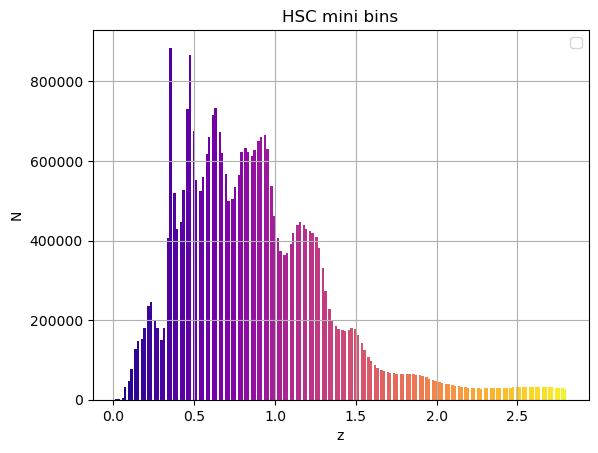

In [4]:
# hsc mini bins
mini_hsc = cf.CorrFileReader(path_dictionary['HSC']).get_bins('HSC')
colormap = plt.get_cmap('plasma')
# get sigmaj for two adjacents bins (std of redshift distribution in the bin ...)
sigmaj_corr = []
zmid = []
for i in range(1, len(mini_hsc)):
    z_bin = zcat[(zcat > mini_hsc[i-1]) & (zcat <= mini_hsc[i])]
    zmid.append(np.mean(z_bin))
    # careful : it's 1/std of the redshift distribution in the bin
    sigmaj_corr.append(np.std(z_bin))
    plt.hist(
        z_bin, 
        bins=2, 
        color=colormap(i/len(mini_hsc)),
        )
plt.xlabel('z')
plt.ylabel('N')
plt.title('HSC mini bins')
plt.grid()
plt.legend()

Text(0.5, 1.0, '$\\sigma_j$ corrections for minibins_j64_ns256_sp0_04')

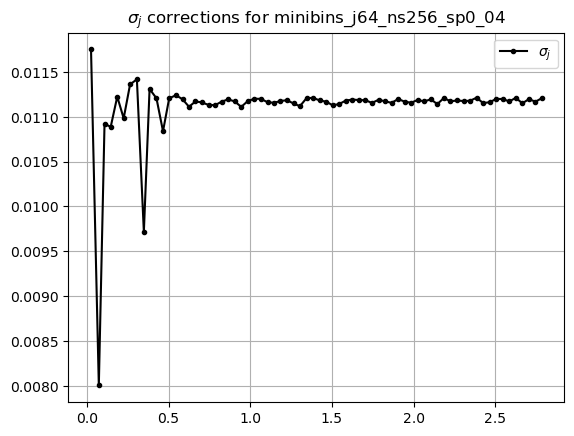

In [5]:
plt.plot(zmid, np.array(sigmaj_corr), marker='o', markersize=3, color='black', label=r'$\sigma_j$')
plt.legend()
plt.grid()
plt.title(r'$\sigma_j$' + f' corrections for {Path(path_dictionary["HSC"]).name}')

In [7]:
importlib.reload(resm)
tracer = 'QSO'
mode = 'DES'
nz = []
for i in range(1, 5):
    kwargs = {
        'path_dictionary' : path_dictionary,
        'scale_cuts' : [0.2, 3.0],
        'tracer' : tracer,
        'tomo_bin' : i,
        'sigmaj_corrections' : sigmaj_corr,
        'verbose' : True,
    }
    print(f"Computing n(z) for tracer {tracer} and tomo bin {i}")
    nz.append(
        resm.full_npz_tomo(
            **kwargs
            )
    )

Computing n(z) for tracer QSO and tomo bin 1
Computing n(z) for tracer QSO and tomo bin 2
Computing n(z) for tracer QSO and tomo bin 3
Computing n(z) for tracer QSO and tomo bin 4


(-2.0, 5.0)

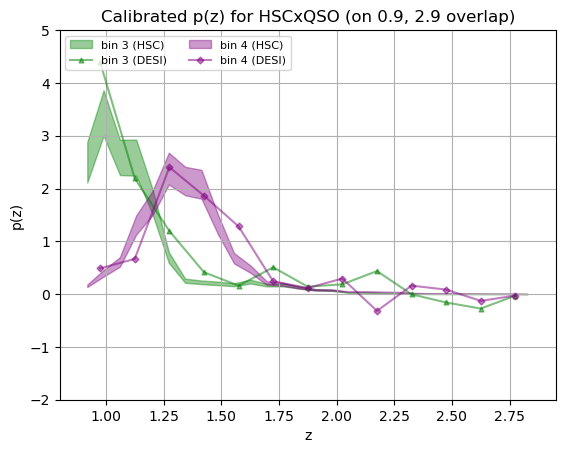

In [8]:
bins_tracer = cf.CorrFileReader(
    path_dictionary['DESI_NGC'],
    ).get_bins(tracer)
bins_hsc = np.arange(0.3, 1.8, 0.3)
colors = ['red', 'blue', 'green', 'purple']
markers = ['x', 's', '^', 'D']
zval = bins_tracer[:-1] + np.diff(bins_tracer) / 2

tomo_bin_dnnz = np.loadtxt('hsc_pz/data/tomographic_binning_dnnz.dat')

mask = (tomo_bin_dnnz[:, 0] >= min(bins_tracer)) & (tomo_bin_dnnz[:, 0] <= max(bins_tracer))
mids = tomo_bin_dnnz[mask, 0]

dnnz_list = []
mu_list = []
cov_list = []
ids_to_skip = []
range_tracer = [bins_tracer[0], bins_tracer[-1]]

for i in range(4):
    if max(range_tracer[0], bins_hsc[i]) > min(range_tracer[1], bins_hsc[i+1]):
        ids_to_skip.append(i)
ncurves = 0
for i in range(4):
    if i in ids_to_skip:
        #pass
        continue
    ncurves += 1

    dnnz, mu, cov = resm.hsc_dnnz_error(tomo_bin_dnnz[mask, i+1], mids)

    plt.fill_between(
        mids, 
        np.percentile(dnnz, 16, axis=0), 
        np.percentile(dnnz, 84, axis=0), 
        color=colors[i], 
        label=f'bin {i+1} (HSC)',
        alpha=0.4
        )
    plt.plot(
        zval, 
        nz[i]/simpson(nz[i], x=zval), 
        marker=markers[i], 
        markersize=3.5, 
        linestyle='-',  
        alpha=0.5,
        color=colors[i],
        label=f'bin {i+1} (DESI)'
        )
    
plt.xlabel('z')
plt.ylabel('p(z)')
plt.grid()
plt.legend(fontsize=8, ncols=ncurves, loc='upper left')
plt.title(f'Calibrated p(z) for HSCx{tracer} (on {min(bins_tracer):.1f}, {max(bins_tracer):.1f} overlap)')
plt.xlim(min(bins_tracer)-0.1, max(bins_tracer)+0.1)
plt.ylim(-2, 5)

In [9]:
importlib.reload(resm)
data = []
# wsp_meas, wpp_meas, wss_meas, hsc_bias, desi_bias, deltaz, zloc, result
for i in range(1, 5):
    print(f"Computing n(z) for tracer {tracer} and tomo bin {i}")
    data.append(
        resm.full_npz_tomo(
            path_dictionary=path_dictionary,
            scale_cuts=[0.5, 5.0],
            tracer=tracer,
            tomo_bin=i,
            verbose=True,
            return_chunks=True,
            sigmaj_corrections=np.ones_like(sigmaj_corr),
            )
    )

Computing n(z) for tracer QSO and tomo bin 1
Computing n(z) for tracer QSO and tomo bin 2
Computing n(z) for tracer QSO and tomo bin 3
Computing n(z) for tracer QSO and tomo bin 4


Text(0, 0.5, 'w')

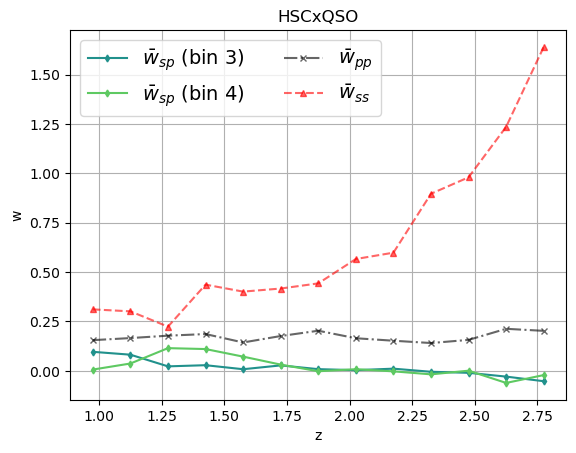

In [10]:
#wsp_meas, wpp_meas, wss_meas, hsc_bias, desi_bias, deltaz, zloc, result
cmap = plt.get_cmap('viridis')
for i in range(4):
    if i in ids_to_skip:
        #pass
        continue
    plt.plot(
        zval, 
        data[i][:, 0], 
        label=r'$\bar{w}_{sp}$' + f' (bin {i+1})', 
        color=cmap(i/4),
        marker='d',
        markersize=3.5,
        )
#plt.plot(
#    zval, 
#    resm.desi_bias_evolution(zval, tracer=tracer), 
#    label='DESI bias model', 
#    color='red', 
#    alpha=1, 
#    linestyle='-'
#    )
plt.plot(
    zval, 
    data[i][:, 1], 
    label=r'$\bar{w}_{pp}$', 
    color='black', 
    alpha=0.6, 
    linestyle='-.', 
    marker='x', 
    markersize=4
    ) 
plt.plot(
    zval, 
    data[i][:, 2], 
    label=r'$\bar{w}_{ss}$', 
    color='red', 
    alpha=0.6, 
    linestyle='--', 
    markersize=4, 
    marker='^'
    )

plt.grid()
plt.legend(loc='upper left', fontsize=14, ncol=2)
plt.title(f'HSCx{tracer}')
plt.xlabel('z')
plt.ylabel('w')

Text(0.5, 1.0, 'Bias models as a function of redshift for tracers')

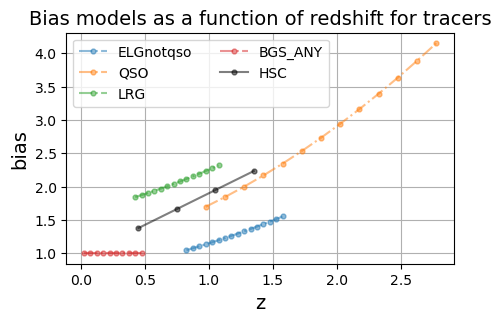

In [11]:
# plot the bias used
importlib.reload(resm)
plt.figure(figsize=(5, 3))
for tracer in ['ELGnotqso', 'QSO', 'LRG', 'BGS_ANY']:
    bins_tracer = cf.CorrFileReader(
        path_dictionary['DESI_NGC'],
    ).get_bins(tracer)
    mids_tracer = bins_tracer[:-1] + np.diff(bins_tracer) / 2
    bias = resm.desi_bias_evolution(z=mids_tracer, tracer=tracer)
    plt.plot(
        mids_tracer, 
        bias, 
        marker='o', 
        markersize=3.5, 
        linestyle='-.',  
        alpha=0.5,
        label=f'{tracer}'
    )
mids_hsc = bins_hsc[:-1] + np.diff(bins_hsc) / 2
plt.plot(
    mids_hsc,
    resm.hsc_bias_evolution(z=mids_hsc, b=0.95),
    marker='o',
    markersize=3.5,
    linestyle='-',
    alpha=0.5,
    label='HSC',
    color='black'
)
plt.xlabel('z', fontsize=14)
plt.ylabel('bias', fontsize=14)
plt.grid()
plt.legend(ncols=2, loc='upper left', fontsize=10)
plt.title(f'Bias models as a function of redshift for tracers',  fontsize=14)

Tracer BGS_ANY
Computing n(z) for tracer BGS_ANY and tomo bin 1
Computing n(z) for tracer BGS_ANY and tomo bin 2
Computing n(z) for tracer BGS_ANY and tomo bin 3
Computing n(z) for tracer BGS_ANY and tomo bin 4
Computing n(z) for tracer BGS_ANY and tomo bin 1
Computing n(z) for tracer BGS_ANY and tomo bin 2
Computing n(z) for tracer BGS_ANY and tomo bin 3
Computing n(z) for tracer BGS_ANY and tomo bin 4
Computing n(z) for tracer BGS_ANY and tomo bin 1
Computing n(z) for tracer BGS_ANY and tomo bin 2
Computing n(z) for tracer BGS_ANY and tomo bin 3
Computing n(z) for tracer BGS_ANY and tomo bin 4
Computing n(z) for tracer BGS_ANY and tomo bin 1
Computing n(z) for tracer BGS_ANY and tomo bin 2
Computing n(z) for tracer BGS_ANY and tomo bin 3
Computing n(z) for tracer BGS_ANY and tomo bin 4
Tracer LRG
Computing n(z) for tracer LRG and tomo bin 1
Computing n(z) for tracer LRG and tomo bin 2
Computing n(z) for tracer LRG and tomo bin 3
Computing n(z) for tracer LRG and tomo bin 4
Computing 

Text(0.5, 0.98, 'Calibrated p(z) for HSC\nroot : outputs')

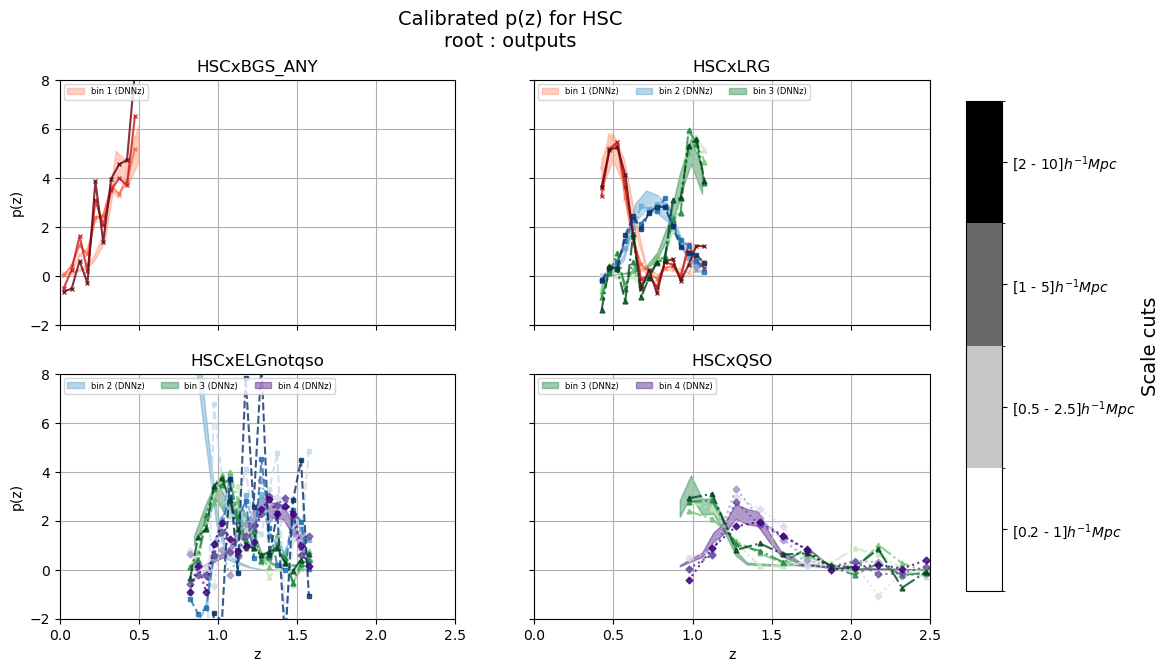

In [33]:
importlib.reload(resm)
scale_cuts = [[0.2, 1], [0.5, 2.5], [1, 5], [2, 10]]
tracers = ['BGS_ANY', 'LRG', 'ELGnotqso', 'QSO']

# tomographic binning...
bins_hsc = np.arange(0.3, 1.8, 0.3)

colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
markers = ['x', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']

tomo_bin_dnnz = np.loadtxt('hsc_pz/data/tomographic_binning_dnnz.dat')

fig, axs = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=True)
fig.subplots_adjust(right=0.85) 
axs = axs.flatten()

for n in range(len(tracers)):
    t = tracers[n]
    ax = axs[n]
    print(f"Tracer {t}")
    bins_tracer = cf.CorrFileReader(
        path_dictionary['DESI_NGC'],
        ).get_bins(t)
    zval = bins_tracer[:-1] + np.diff(bins_tracer) / 2
    range_tracer = [bins_tracer[0], bins_tracer[-1]]
    mask = (tomo_bin_dnnz[:, 0] >= min(bins_tracer)) & (tomo_bin_dnnz[:, 0] <= max(bins_tracer))
    mids = tomo_bin_dnnz[mask, 0]

    dnnz_list = []
    mu_list = []
    cov_list = []

    for k, sc in enumerate(scale_cuts):

        ids_to_skip = []
        nz = []

        for tomo in range(1, 5):
            print(f"Computing n(z) for tracer {t} and tomo bin {tomo}")
            nz.append(
                resm.full_npz_tomo(
                    path_dictionary=path_dictionary,
                    scale_cuts=sc,
                    tracer=t,
                    tomo_bin=tomo,
                    sigmaj_corrections=np.ones_like(sigmaj_corr),
                    rebin=2,
                    )
            )

        for j in range(4):
            if max(range_tracer[0], bins_hsc[j]) > min(range_tracer[1], bins_hsc[j+1]):
                ids_to_skip.append(j)
                continue
            ncurves = 0
            ax.plot(
                zval, 
                nz[j]/simpson(nz[j], x=zval), 
                marker=markers[j], 
                linestyle=linestyles[j],
                markersize=3.5,   
                alpha=0.8,
                color=colormaps[j]((k+1)/4),
                )

    for m in range(4):
        if m not in ids_to_skip:
            ncurves += 1

            dnnz, mu, cov = resm.hsc_dnnz_error(tomo_bin_dnnz[mask, m+1], mids)

            ax.fill_between(
                mids, 
                np.percentile(dnnz, 16, axis=0), 
                np.percentile(dnnz, 84, axis=0), 
                color=colormaps[m]((m+2)/5), 
                label=f'bin {m+1} (DNNz)',
                alpha=0.4
                )
    if n == 2 or n == 3: 
        ax.set_xlabel('z')
    if n == 0 or n == 2:
        ax.set_ylabel('p(z)')
    ax.grid()
    ax.legend(fontsize=6, ncols=4, loc='upper left')
    ax.set_title(f'HSCx{t}')
    #ax.set_xlim(min(bins_tracer)-0.05, max(bins_tracer)+0.05)
    ax.set_xlim(0, 2.5)
    ax.set_ylim(-2, 8)

cmap = plt.cm.Greys
scale_levels = np.arange(0, len(scale_cuts)+1, 1)
norm = BoundaryNorm(boundaries=scale_levels, ncolors=cmap.N, extend='neither')

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
scale_ticks = scale_levels[:-1] + 0.5
cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7])
cbar = fig.colorbar(sm, cax=cbar_ax, ticks=scale_ticks)
cbar.set_ticklabels([f'[{sc[0]} - {sc[1]}]' + r'$h^{-1}Mpc$' for sc in scale_cuts])
cbar.set_label('Scale cuts', fontsize=14)

fig.suptitle(f'Calibrated p(z) for HSC\nroot : {ROOT.name}', fontsize=14)

## $r_{cc}$ analysis on simulations

------------------------------------

In [43]:
importlib.reload(resm)
ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/')
desc = 'j64_ns256'
path_dictionary = {
    'HSC' : ROOT / 'results_sims_rcc_v2_0_1' / f'autos_{desc}_zbin', #quasar spacing bla bla bla
    'DESI_NGC' : ROOT / 'results_sims_rcc_v2_0_1' / f'autos_{desc}_zbin',
    'DESI_SGC' : None, #ROOT / f'autos_{desc}_SGC',
    'DESIxHSC' : ROOT / 'results_sims_rcc_v2_0_1' / f'autos_{desc}_zbin',
}
for v in path_dictionary.values():
    if v is not None:
        assert Path(v).is_dir(), f"Path {v} does not exist as a directory. Please check the path."

In [82]:
importlib.reload(resm)
scale_cuts = [0.01, 200]
tracer_rcc1 = 'ELGnotqso'
tracer_rcc2 = 'LRG'
frcc = resm.full_rcc(
    path_dictionary=path_dictionary,
    tracer1=tracer_rcc1,
    tracer2=tracer_rcc2,
    scale_cuts=scale_cuts,
    rebin=4
    )

tracer1_redshift : [0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6], tracer1_bins : [1 2 3]
tracer2_redshift : [0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1], tracer2_bins : [5 6 7 8 8 8 8 8 8]
NGC estimator : <pycorr.twopoint_estimator.DavisPeeblesTwoPointEstimator object at 0x7f640ee56610>, SGC estimator : None, bin_index1 : 5, bin_index2 : 5, tracer1 : LRG, tracer2 : LRG
NGC estimator : <pycorr.twopoint_estimator.DavisPeeblesTwoPointEstimator object at 0x7f641c259e90>, SGC estimator : None, bin_index1 : 1, bin_index2 : 1, tracer1 : ELGnotqso, tracer2 : ELGnotqso
NGC estimator : <pycorr.twopoint_estimator.DavisPeeblesTwoPointEstimator object at 0x7f640efbd790>, SGC estimator : None, bin_index1 : 1, bin_index2 : 5, tracer1 : ELGnotqso, tracer2 : LRG
wsp_meas : [0.68683473 0.356497   0.1770928  0.1368809  0.10250244 0.05913034
 0.02957318 0.01005471], wss_meas : [0.42695048 0.30418099 0.17042437 0.11840859 0.07966204 0.03587676
 0.0151146  0.0049758 ], wpp_meas : [3.05606114 1.20161801 0.59381864 0.43458674 0

In [83]:
for r in frcc:
    print(r)

[0.60128792 0.58966673 0.55668325 0.6034107  0.67612133 0.82096454
 0.94805304 0.95416697]
[0.56156857 0.56943138 0.48558622 0.50846835 0.59700499 0.70562329
 0.87963393 1.06807065]
[0.41335915 0.56680266 0.51618161 0.51097427 0.45880456 0.5466495
 1.00688621        nan]


zval : [0.45 0.55 0.65 0.75 0.85 0.95 1.05]
8
8
8


Text(0.5, 1.0, '$r_{cc}$ for ELGnotqsoxLRG')

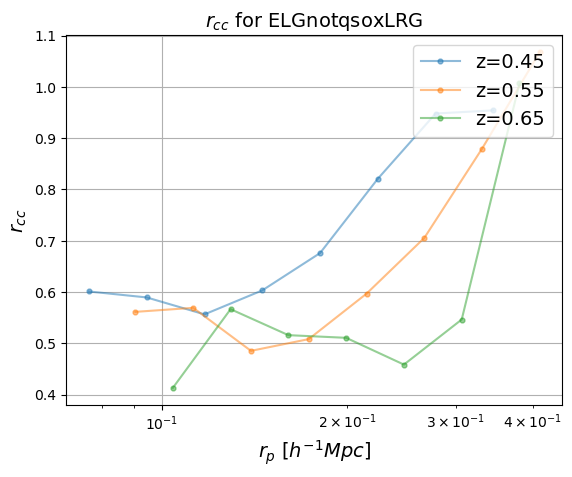

In [87]:
import src.statistics.cosmotools as ct
reader = cf.CorrFileReader(
    path_dictionary['DESI_NGC'],
    )
bins_lrg = reader.get_bins(tracer_rcc2)
sep = reader.get_bins('theta')

zval = bins_lrg[:-1] + np.diff(bins_lrg) / 2
print(f"zval : {zval}")

for i, r in enumerate(frcc):
    scale = ct.arcsec2hMpc(sep*3600, zval[i])
    # for now at LRG redshifts these are the same since minimum scale is > 0.1
    scale = scale[:len(r)]
    print(len(r))
    plt.plot(scale, r, marker='o', markersize=3.5, linestyle='-', alpha=0.5, label=f'z={zval[i]:.2f}')
plt.xscale('log')
plt.xlabel(r'$r_p$ [$h^{-1}Mpc$]', fontsize=14)
plt.ylabel(r'$r_{cc}$', fontsize=14)
plt.grid()
plt.legend(loc='upper right', fontsize=14)
plt.title(r'$r_{cc}$' + f' for {tracer_rcc1}x{tracer_rcc2}', fontsize=14)

TypeError: Dimensions of C (100, 3) should be one smaller than X(7) and Y(100) while using shading='flat' see help(pcolormesh)

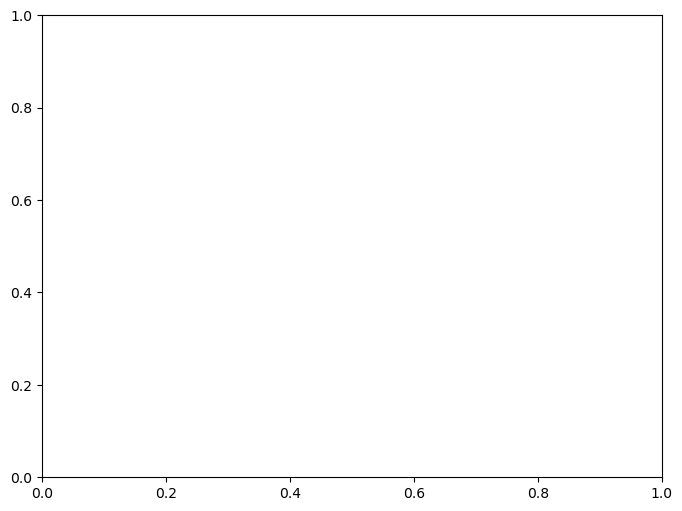

In [ ]:
rcc_interp = []
scale_matrix = []

common_scale = np.logspace(-1, 1, 100)  # 0.1 to 10 h⁻¹Mpc (adjust as needed)

for i, r in enumerate(frcc):
    r_p = ct.arcsec2hMpc(sep * 3600, zval[i])[:len(r)]
    interp = interp1d(r_p, r, bounds_error=False, fill_value=np.nan)
    rcc_interp.append(interp(common_scale))

rcc_interp = np.array(rcc_interp)  # shape (n_z, n_common_scale)
Z, R = np.meshgrid(zval, common_scale)

# Step 2: Discrete levels and colormap
levels = [0.4, 0.6, 0.75, 0.85, 0.95, 1.05, 1.15, 1.25, 1.4, 1.6]  # 5 intervals = 6 boundaries
cmap = plt.get_cmap('coolwarm', len(levels)-1)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, clip=True)

# Step 3: Plot
plt.figure(figsize=(8, 6))
pc = plt.pcolormesh(Z, R, rcc_interp.T, cmap=cmap, norm=norm, shading='auto')
plt.yscale('log')
plt.xlabel(r'$z$', fontsize=14)
plt.ylabel(r'$r_p$ [$h^{-1}\,\mathrm{Mpc}$]', fontsize=14)
plt.title(r'Discrete $r_{cc}(r_p, z)$ (BGS)', fontsize=14)

# Discrete colorbar
cbar = plt.colorbar(pc, ticks=levels, label=r'$r_{cc}$')
cbar.ax.set_yticklabels([f"{lvl:.2f}" for lvl in levels])  # optional: format tick labels

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
